# Airbnb Amsterdam Listings Analysis(EDA)

## Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

## Data loading

In [2]:
listings = pd.read_csv('listings.csv')
reviews = pd.read_csv('reviews.csv')

In [3]:
listings.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license'],
      dtype='object')

In [4]:
listings.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group               float64
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
license                            object
dtype: object

## Data Cleaning

### Checking for missing values

In [5]:
print(listings.isnull().sum())

# Fill missing values (if applicable)
listings['name'].fillna('No Name', inplace=True)
listings['reviews_per_month'].fillna(0, inplace=True)

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group               10032
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                              3742
minimum_nights                        0
number_of_reviews                     0
last_review                        1090
reviews_per_month                  1090
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                              94
dtype: int64


C:\Users\κική\AppData\Local\Temp\ipykernel_7568\2751709751.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  listings['name'].fillna('No Name', inplace=True)
C:\Users\κική\AppData\Local\Temp\ipykernel_7568\2751709751.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

### Handling Duplicates

In [6]:
listings.drop_duplicates(inplace=True)

### Fixing Data Types

In [7]:
listings['last_review'] = pd.to_datetime(listings['last_review'], errors='coerce')

## Overall Summary

### How many listings are there?

In [8]:
print(f"Total listings: {listings.shape[0]}")

Total listings: 10032


### Distribution of room types

<Axes: title={'center': 'Room Type Distribution (Amsterdam)'}, xlabel='room_type'>

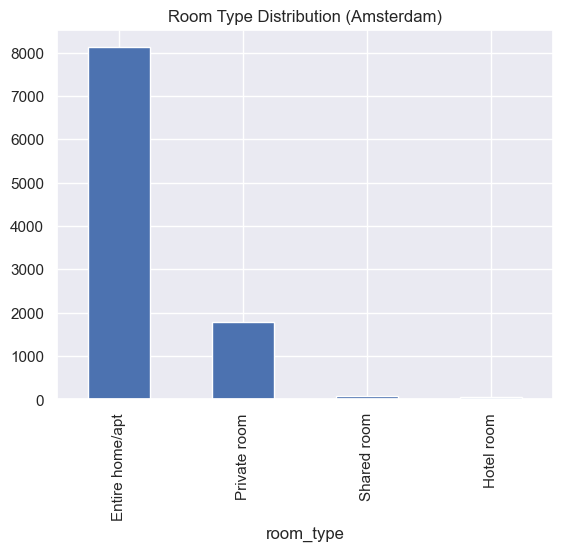

In [9]:
sns.set_theme()
room_type_counts = listings['room_type'].value_counts()
room_type_counts.plot(kind='bar', title='Room Type Distribution (Amsterdam)')

## Pricing Trends

### Distribution of prices

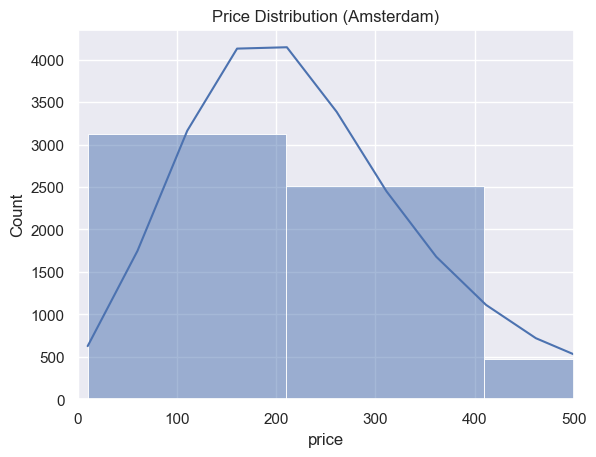

In [10]:
sns.set_theme()
sns.histplot(listings['price'], bins=50, kde=True)
plt.xlim(0, 500)
plt.title('Price Distribution (Amsterdam)')
plt.show()

As it is seen above, the average price most people prefer to rent for an airbnb is close to 180 euros as the distribution shows 

### Average Price by Room Type

<Axes: title={'center': 'Average Price by Room Type (Amsterdam)'}, xlabel='room_type'>

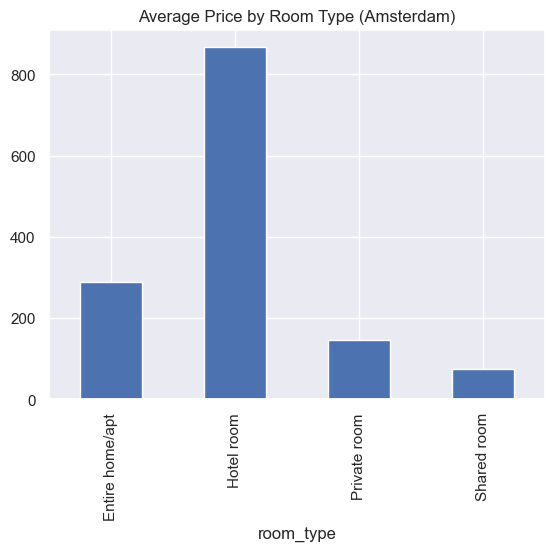

In [11]:
# listings['price'].value_counts()
sns.set_theme()
avg_room_type = listings.groupby('room_type')['price'].mean()
avg_room_type.plot(kind = 'bar', title='Average Price by Room Type (Amsterdam)')

As it is seen above, most people prefer to rent a hotel room or an apartment 

### Average price by neighborhood

<Axes: title={'center': 'Average Price by Neighborhood (Amsterdam)'}, xlabel='neighbourhood'>

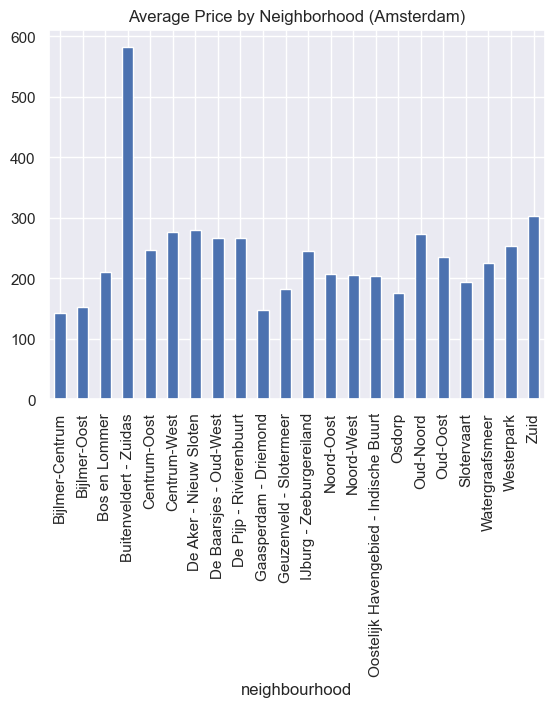

In [12]:
avg_price_neighborhood = listings.groupby('neighbourhood')['price'].mean()
avg_price_neighborhood.plot(kind='bar', title='Average Price by Neighborhood (Amsterdam)')

## Geographical Analysis

### Visualize listings on a map

In [13]:
import folium
map_thess = folium.Map(location=[40.629269, 22.947412], zoom_start=10)
for _, row in listings.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=1,
        color='blue',
        fill=True
    ).add_to(map_thess)

map_thess.save("amst_listings_map.html")

### Listings by neighborhood

<Axes: title={'center': 'Listings by Neighborhood Group (Amsterdam)'}, ylabel='count'>

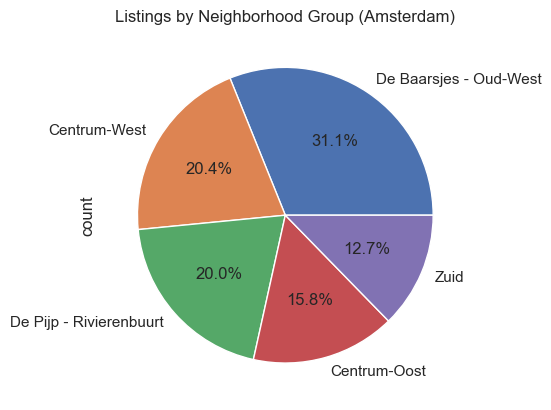

In [14]:
sns.set_theme()
neighborhood_counts = listings['neighbourhood'].value_counts().head()
neighborhood_counts.plot(kind='pie', autopct='%1.1f%%', title='Listings by Neighborhood Group (Amsterdam)')

## Availability and Reviews

### Distribution of minimum nights

C:\Users\κική\AppData\Local\Temp\ipykernel_7568\114725457.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=30)


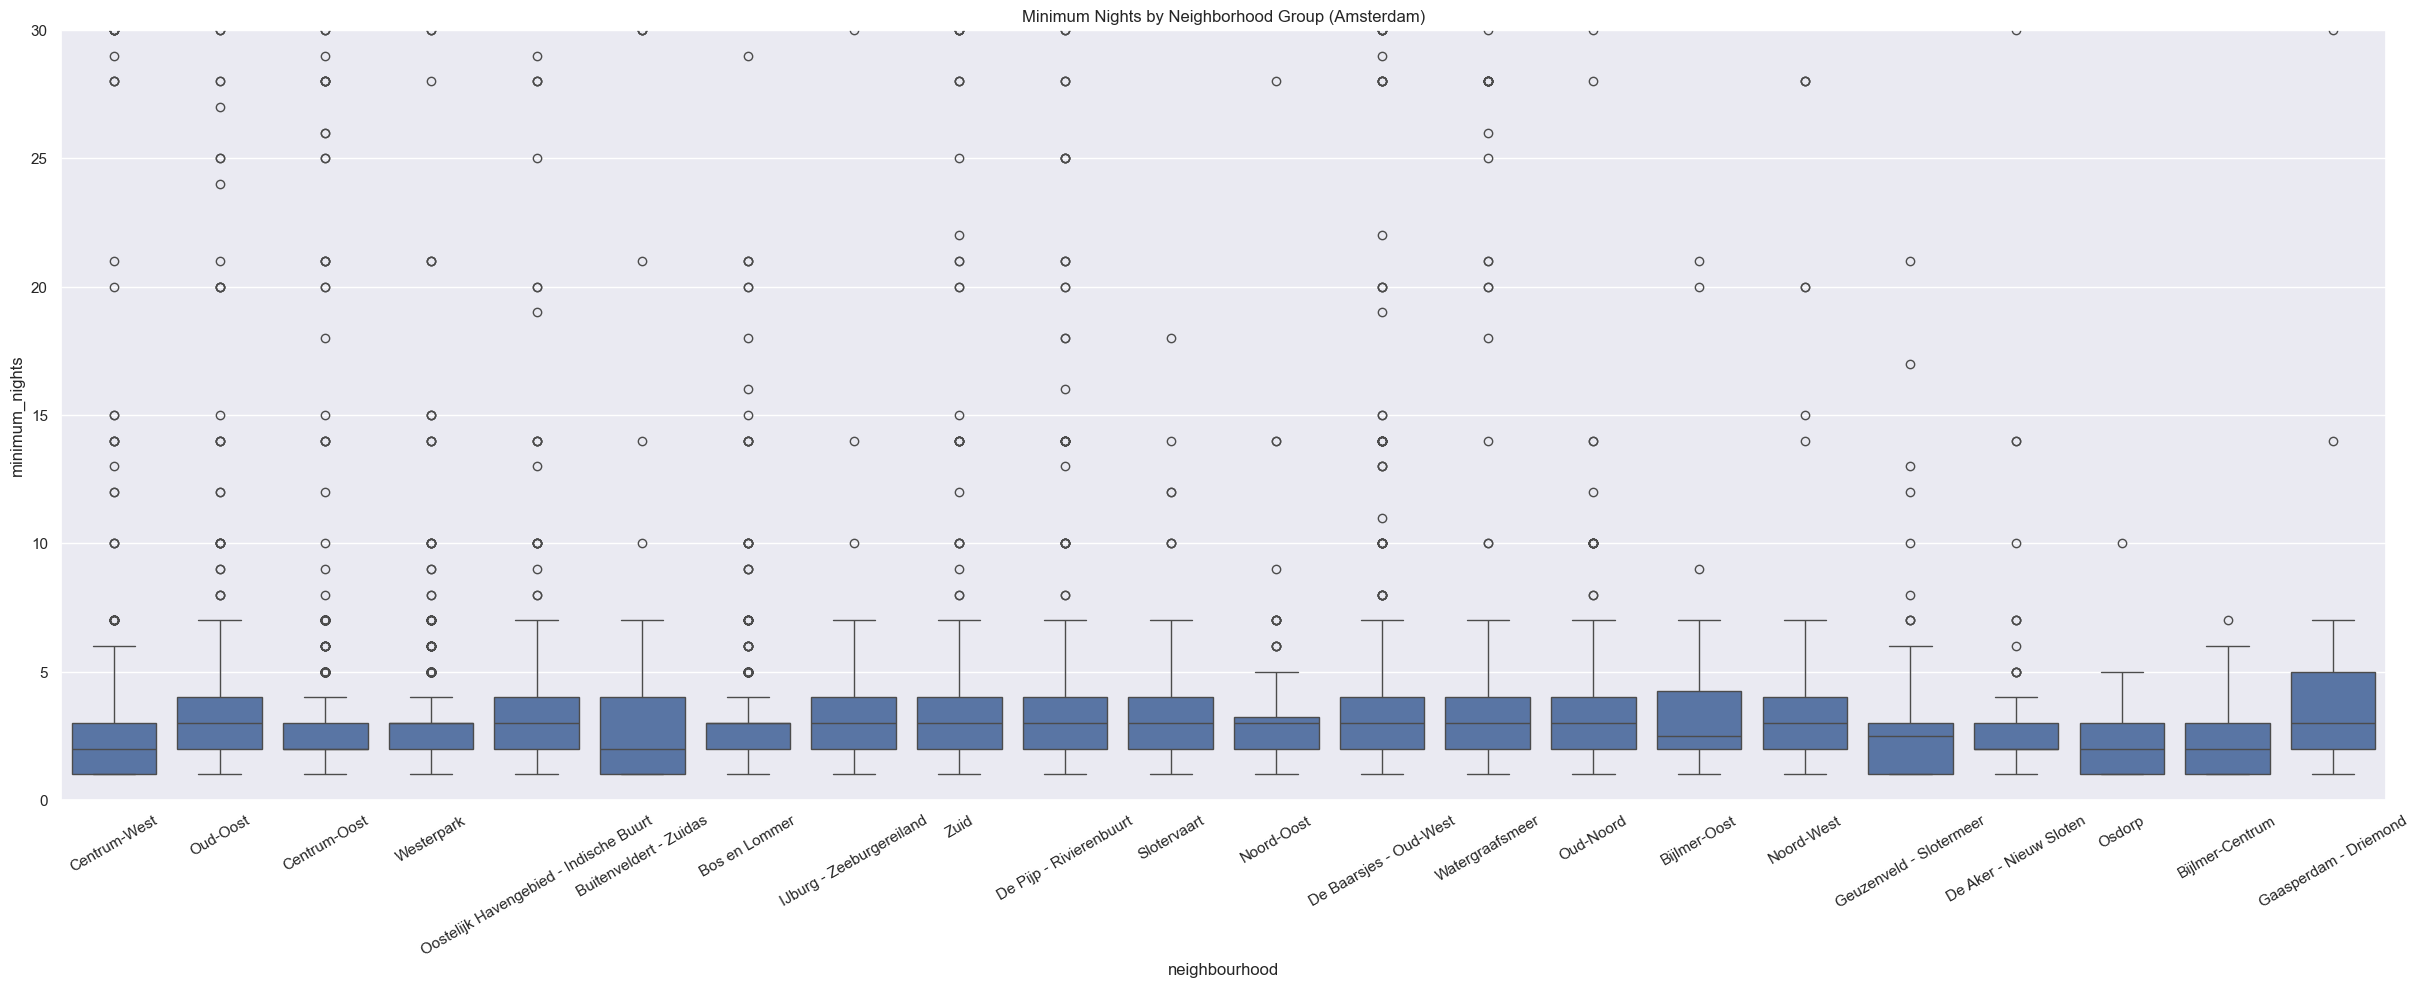

In [15]:
sns.set_theme()
plt.figure(figsize=(30,10))
ax = sns.boxplot(x='neighbourhood', y='minimum_nights', data=listings)
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)
plt.ylim(0, 30)
plt.title('Minimum Nights by Neighborhood Group (Amsterdam)')
plt.show()

### Reviews per month

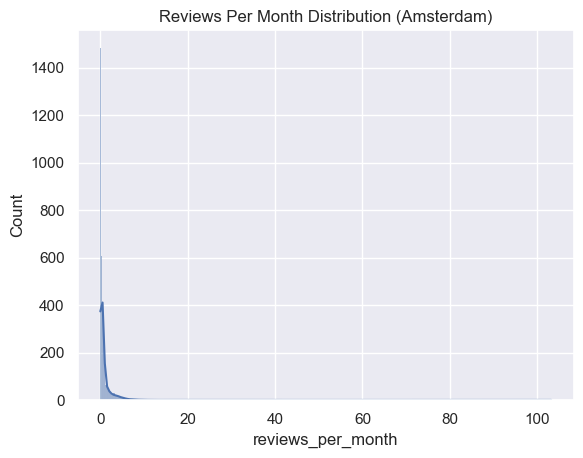

In [16]:
sns.set_theme()
sns.histplot(listings['reviews_per_month'], kde=True)
plt.title('Reviews Per Month Distribution (Amsterdam)')
plt.show()

### Availability based on minimum nights

<Axes: title={'center': 'Availability by minimum nights (Amsterdam)'}, xlabel='minimum_nights'>

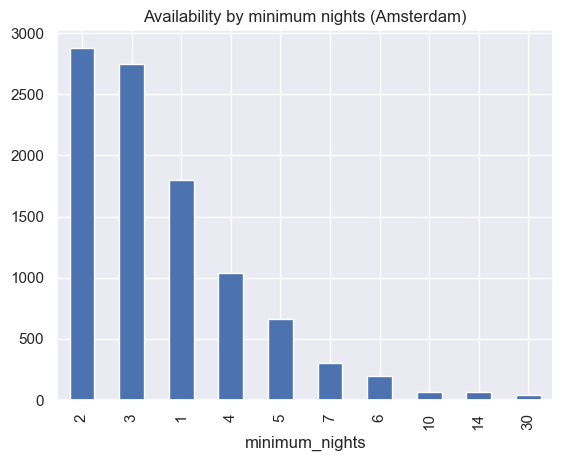

In [17]:
sns.set_theme()
m_nights = listings['minimum_nights'].value_counts().head(10)
m_nights.plot(kind='bar', title='Availability by minimum nights (Amsterdam)')

### Reviews and lower prices 

In [18]:
listings[['number_of_reviews','price']].value_counts().head(20)
# listings['number_of_reviews'].value_counts(ascending=True)
#.value_counts(ascending=True).head(50)

number_of_reviews  price
0                  200.0    44
1                  200.0    27
0                  350.0    27
                   250.0    23
                   150.0    22
2                  250.0    21
1                  300.0    20
4                  200.0    19
3                  250.0    19
0                  300.0    17
2                  200.0    17
6                  250.0    17
2                  300.0    16
4                  250.0    16
3                  200.0    16
1                  250.0    15
7                  200.0    14
9                  250.0    13
5                  200.0    13
3                  350.0    13
Name: count, dtype: int64

### Room Type

In [19]:
rtype = listings['room_type'].value_counts()
rtype
# rtype.plot(kind='bar', title="Room Type")

room_type
Entire home/apt    8118
Private room       1790
Shared room          69
Hotel room           55
Name: count, dtype: int64

### Last review varies across neighbour

In [20]:
sns.set_theme()
last_neigh = listings.groupby('neighbourhood')['last_review'].value_counts().head(60)
last_neigh
# sns.histplot(last_neigh)
# plt.title('Reviews Per Month Distribution')
# plt.show()

neighbourhood    last_review
Bijlmer-Centrum  2024-12-01     5
                 2024-11-22     3
                 2024-11-23     3
                 2024-11-24     3
                 2024-06-30     2
                 2024-10-20     2
                 2024-10-21     2
                 2024-11-04     2
                 2024-11-11     2
                 2024-11-17     2
                 2017-03-26     1
                 2019-08-05     1
                 2022-05-29     1
                 2022-08-07     1
                 2022-08-16     1
                 2023-04-27     1
                 2023-08-20     1
                 2023-08-28     1
                 2023-10-23     1
                 2024-01-10     1
                 2024-05-24     1
                 2024-06-20     1
                 2024-06-26     1
                 2024-07-07     1
                 2024-07-08     1
                 2024-07-12     1
                 2024-07-30     1
                 2024-08-23     1
                 20

### Analyse trends over time based on last review

In [21]:
listings = listings.dropna(subset=['last_review'])

In [22]:
# Group by 'neighbourhood' and calculate review trends
review_trends = listings.groupby(['neighbourhood', 'last_review']).size().reset_index(name='review_count')

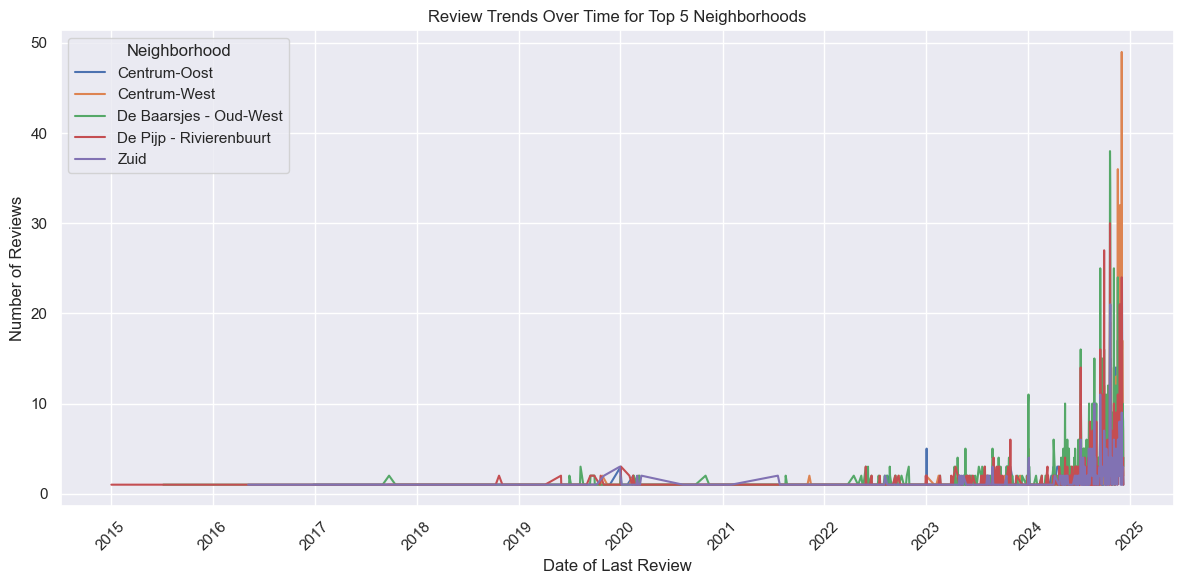

In [23]:
# Visualize review trends over time for the top 5 neighborhoods by total reviews
top_neighborhoods = listings.groupby('neighbourhood')['number_of_reviews'].sum().nlargest(5).index
filtered_trends = review_trends[review_trends['neighbourhood'].isin(top_neighborhoods)]

sns.set_theme()
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=filtered_trends,
    x='last_review',
    y='review_count',
    hue='neighbourhood'
)
plt.title('Review Trends Over Time for Top 5 Neighborhoods')
plt.xlabel('Date of Last Review')
plt.ylabel('Number of Reviews')
plt.legend(title='Neighborhood')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

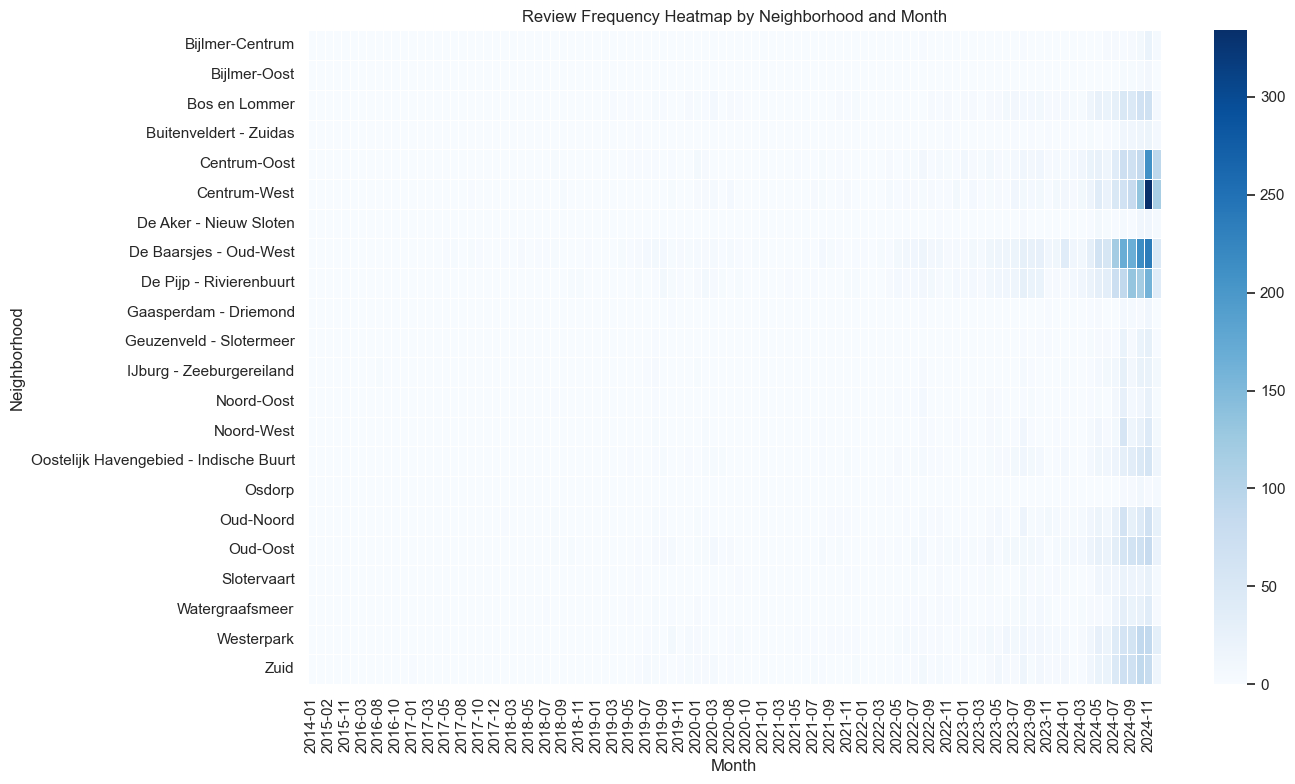

In [24]:
# Heatmap of review frequency by neighborhood and month
listings['month'] = listings['last_review'].dt.to_period('M')
heatmap_data = listings.groupby(['neighbourhood', 'month']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap='Blues', linewidths=0.5)
plt.title('Review Frequency Heatmap by Neighborhood and Month')
plt.xlabel('Month')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()

## Building a predictive model to forecast pricing or occupancy rates

### Import the libraries

In [25]:
import numpy as np
from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# from xgboost import XGBRegressor

### Defining the target and features

In [26]:
# Drop rows with missing prices
listings = listings.dropna(subset=['price']) 
# listings['price'] = listings['price'].astype(float)

In [27]:
# Dropping columns
columns_to_drop = ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group','license', 'last_review']
data_cleaned = listings.drop(columns=columns_to_drop)

In [28]:
# Interpolating 'lat' and 'long' based on 'neighbourhood'
# Grouping by 'neighbourhood' and calculating the mean 'lat' and 'long'
mean_coords = data_cleaned.groupby('neighbourhood')[['latitude', 'longitude']].mean()

# Applying the mean coordinates to missing values
data_cleaned = data_cleaned.set_index('neighbourhood')
data_cleaned['latitude'].fillna(mean_coords['latitude'], inplace=True)
data_cleaned['longitude'].fillna(mean_coords['longitude'], inplace=True)
data_cleaned.reset_index(inplace=True)

C:\Users\κική\AppData\Local\Temp\ipykernel_7568\1276043876.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned['latitude'].fillna(mean_coords['latitude'], inplace=True)
C:\Users\κική\AppData\Local\Temp\ipykernel_7568\1276043876.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [29]:
# Filling columns about numerical data with median and mean
numerical_columns = ['minimum_nights', 'number_of_reviews',
                     'reviews_per_month', 'calculated_host_listings_count',
                     'availability_365']
for col in numerical_columns:
    data_cleaned[col].fillna(data_cleaned[col].median(), inplace=True)

C:\Users\κική\AppData\Local\Temp\ipykernel_7568\100482101.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned[col].fillna(data_cleaned[col].median(), inplace=True)
C:\Users\κική\AppData\Local\Temp\ipykernel_7568\100482101.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [30]:
# Filling columns about numerical data with mode
categorical_columns = ['room_type']
for col in categorical_columns:
    data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)

C:\Users\κική\AppData\Local\Temp\ipykernel_7568\2510382449.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)


## Feature Engineering

In [31]:
# Applying one-hot encoding
onehot_encoder = OneHotEncoder(sparse_output=False, drop='first') # drop='first' to avoid multicollinearity
encoded_data = pd.DataFrame(onehot_encoder.fit_transform(data_cleaned[categorical_columns]))
encoded_data.columns = onehot_encoder.get_feature_names_out(categorical_columns)

In [32]:
# Dropping original categorical columns and adding encoded columns
#data_fe variable created for feature engineering the cleaned data
data_fe = data_cleaned.drop(columns=categorical_columns)
data_fe = pd.concat([data_fe, encoded_data], axis=1)

In [33]:
non_num_columns = ['neighbourhood', 'month']
data_fe = data_fe.drop(columns=non_num_columns,axis=1)
data_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5511 entries, 0 to 5510
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   latitude                        5511 non-null   float64
 1   longitude                       5511 non-null   float64
 2   price                           5511 non-null   float64
 3   minimum_nights                  5511 non-null   int64  
 4   number_of_reviews               5511 non-null   int64  
 5   reviews_per_month               5511 non-null   float64
 6   calculated_host_listings_count  5511 non-null   int64  
 7   availability_365                5511 non-null   int64  
 8   number_of_reviews_ltm           5511 non-null   int64  
 9   room_type_Hotel room            5511 non-null   float64
 10  room_type_Private room          5511 non-null   float64
 11  room_type_Shared room           5511 non-null   float64
dtypes: float64(7), int64(5)
memory usa

In [34]:
data_fe.isnull().sum()

latitude                          0
longitude                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
room_type_Hotel room              0
room_type_Private room            0
room_type_Shared room             0
dtype: int64

In [35]:
data_fe.dtypes

latitude                          float64
longitude                         float64
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
room_type_Hotel room              float64
room_type_Private room            float64
room_type_Shared room             float64
dtype: object

In [36]:
data_fe.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,52.37561,4.90000,134.0,3,475,3.05,2,207,38,0.0,1.0,0.0
1,52.35179,4.91082,155.0,3,271,1.72,1,334,18,0.0,1.0,0.0
2,52.37191,4.89708,117.0,3,333,2.15,1,247,51,0.0,0.0,0.0
3,52.39185,4.88690,356.0,2,103,0.69,2,269,2,0.0,0.0,0.0
4,52.37104,4.87713,325.0,3,95,0.62,1,312,5,0.0,0.0,0.0


## Train-test split

In [37]:
X = data_fe.iloc[:, :-1].values
y = data_fe.iloc[:, -1].values

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Building and training the Model

#### Applying Linear Regression

In [49]:
# linear_reg = LinearRegression()
# linear_reg.fit(X_train, y_train)

#### Applying Decision Tree Regression

In [50]:
decision_tree_reg = DecisionTreeRegressor(random_state=101)
decision_tree_reg.fit(X_train, y_train)

DecisionTreeRegressor(random_state=101)

## Evaluate the model 

In [45]:
# y_pred_linear_reg = linear_reg.predict(X_test)

In [48]:
# mse_linear_reg = mean_squared_error(y_test, y_pred_linear_reg)
# r2_linear_reg = r2_score(y_test, y_pred_linear_reg)

# mse_linear_reg, r2_linear_reg
# (0.0035319561452903264, 0.0012006797969080774)
# (0.009999269118511173, 0.07079126160993299)

(0.009999269118511173, 0.07079126160993299)

In [47]:
# print(f"Mean Squared Error: {mse_linear_reg:.2f}")
# print(f"R^2 Score: {r2_linear_reg:.2f}")

Mean Squared Error: 0.01
R^2 Score: 0.07


In [51]:
# Predicting on the test set
y_pred_decision_tree = decision_tree_reg.predict(X_test)

In [52]:
mse_decision_tree = mean_squared_error(y_test, y_pred_decision_tree)
r2_decision_tree = r2_score(y_test, y_pred_decision_tree)

mse_decision_tree, r2_decision_tree
# (0.003626473254759746, 0.6630003055300948)

(0.003626473254759746, 0.6630003055300948)

In [53]:
print(f"Mean Squared Error: {mse_decision_tree:.2f}")
print(f"R^2 Score: {r2_decision_tree:.2f}")

Mean Squared Error: 0.00
R^2 Score: 0.66
